# HelixHeatX with pythonnet

This notebook runs on the `LEAP71_wrapper` conda environment and uses the pythonnet-based wrapper to call the compiled C# HelixHeatX task.

In [1]:
from pathlib import Path
import sys

root = Path.cwd()
if not (root / 'leap71_wrapper.py').exists():
    root = root.parent
sys.path.insert(0, str(root))

from leap71_wrapper import Leap71Workspace

workspace = Leap71Workspace.discover(root)
stl_path = workspace.generate_helix_heatx(voxel_size=0.5)
stl_path

WindowsPath('C:/Users/lhuir/Downloads/PicoGK_Examples-main/Examples/HelixHeatX.STL')

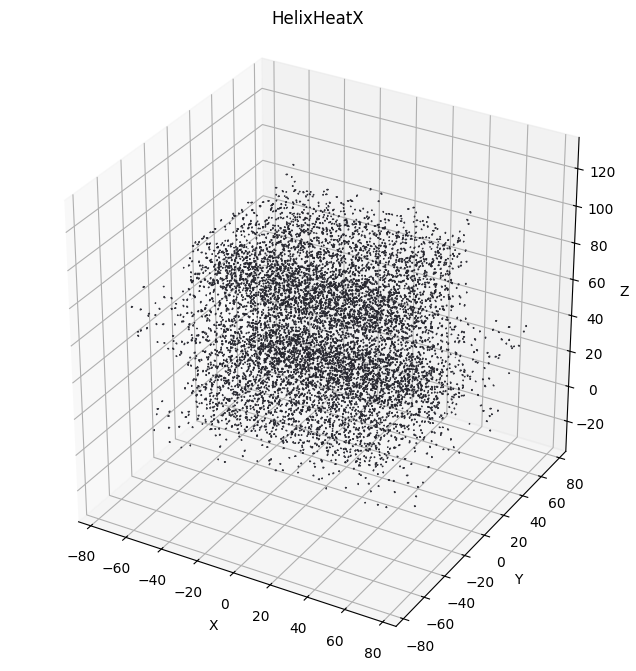

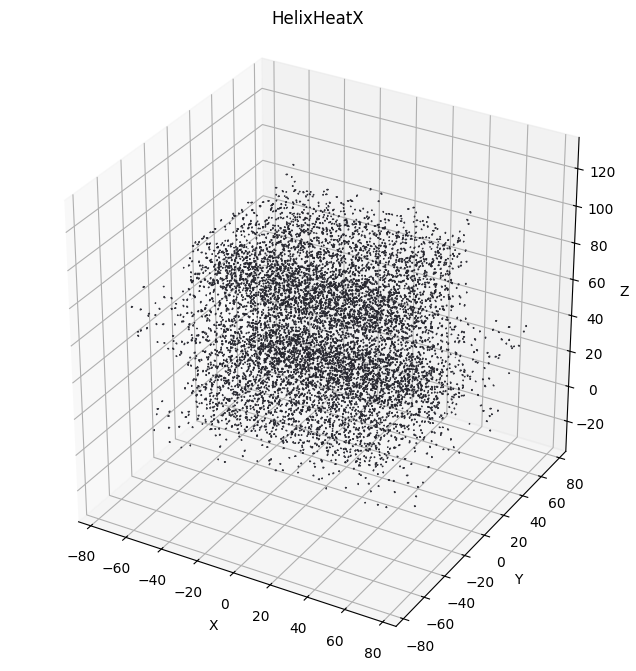

In [2]:
from stl import mesh as stl_mesh
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
import numpy as np

mesh_obj = stl_mesh.Mesh.from_file(str(stl_path))
vectors = mesh_obj.vectors
if len(vectors) > 8000:
    step = max(1, len(vectors) // 8000)
    vectors = vectors[::step]

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
collection = Poly3DCollection(vectors, alpha=0.92)
collection.set_facecolor((0.22, 0.45, 0.78, 0.92))
collection.set_edgecolor((0.15, 0.15, 0.18, 0.12))
ax.add_collection3d(collection)

points = vectors.reshape(-1, 3)
mins = points.min(axis=0)
maxs = points.max(axis=0)
spans = np.maximum(maxs - mins, 1e-6)
centers = (mins + maxs) / 2.0
radius = spans.max() / 2.0

ax.set_xlim(centers[0] - radius, centers[0] + radius)
ax.set_ylim(centers[1] - radius, centers[1] + radius)
ax.set_zlim(centers[2] - radius, centers[2] + radius)
ax.set_box_aspect([1, 1, 1])
ax.set_title('HelixHeatX')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

fig

In [3]:
print(f'Generated triangles: {len(mesh_obj.vectors)}')
print(stl_path)

Generated triangles: 10057668
C:\Users\lhuir\Downloads\PicoGK_Examples-main\Examples\HelixHeatX.STL
